<a href="https://colab.research.google.com/github/Deepika-Ch19/Network-intrusion-detection/blob/main/Network_intrusion_Detection_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading the Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Reading the CSV File

In [2]:
filepath='/content/drive/MyDrive/Midterm_53_group.csv'
df = pd.read_csv(filepath)
df.dropna(inplace=True)
df.head()

,Time,Source,No.,Destination,Protocol,Length,Info
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
3,2.167949,VMware_8a:5c:e6,4,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
4,3.170095,VMware_8a:5c:e6,5,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1


#Processed Data ready for Modelling

In [3]:
df = pd.get_dummies(df, columns=["Protocol"], drop_first=True)
df["is_query"] = df["Info"].str.contains("query", case=False).astype(int)
df.drop(columns=["Info", "Source", "Destination"], inplace=True)
scaler = MinMaxScaler()
df[["Time", "Length"]] = scaler.fit_transform(df[["Time", "Length"]])
df.head()

,Time,No.,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,Protocol_ICMPv6,Protocol_NBNS,Protocol_OCSP,Protocol_RARP,Protocol_SSLv2,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query
0,0.000000,1,0.001006,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,1
1,0.000624,2,0.001006,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,1
2,0.000930,3,0.000362,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
3,0.001725,4,0.000362,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
4,0.002522,5,0.000362,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0


#Isolation-based Anomaly Detection

In [4]:
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
sample_df = df.sample(n=10000, random_state=42).copy()
sample_df["anomaly"] = model.fit_predict(sample_df[["Time", "Length", "is_query"]])
sample_df["label"] = np.where(sample_df["anomaly"] == -1, 1, 0)
sample_df["predicted"] = sample_df["label"]
df.head()

,Time,No.,Length,Protocol_BROWSER,Protocol_DHCP,Protocol_DNS,Protocol_HTTP,Protocol_ICMP,Protocol_ICMPv6,Protocol_NBNS,Protocol_OCSP,Protocol_RARP,Protocol_SSLv2,Protocol_STUN,Protocol_TCP,Protocol_TLSv1,Protocol_TLSv1.2,Protocol_TLSv1.3,is_query
0,0.000000,1,0.001006,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,1
1,0.000624,2,0.001006,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,1
2,0.000930,3,0.000362,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
3,0.001725,4,0.000362,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0
4,0.002522,5,0.000362,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0


#Distribution of Normalised Packet length


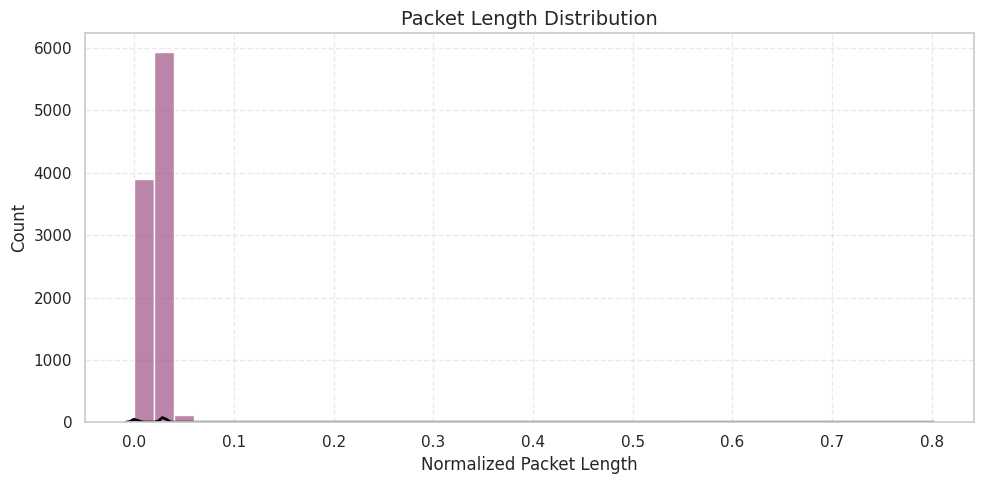

In [5]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(sample_df["Length"], bins=40, kde=False, color=sns.color_palette("flare")[4], alpha=0.6)
sns.kdeplot(sample_df["Length"], color="black", linewidth=2)
plt.title("Packet Length Distribution", fontsize=14)
plt.xlabel("Normalized Packet Length")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#Packet Length Distribution by Anomaly Class

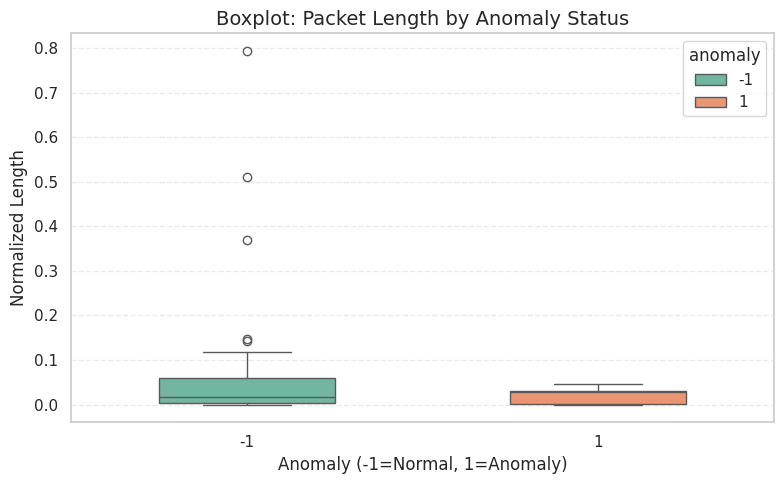

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="anomaly", y="Length", data=sample_df,hue="anomaly", palette="Set2", width=0.5)
plt.title("Boxplot: Packet Length by Anomaly Status", fontsize=14)
plt.xlabel("Anomaly (-1=Normal, 1=Anomaly)")
plt.ylabel("Normalized Length")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#Correlation Heatmap

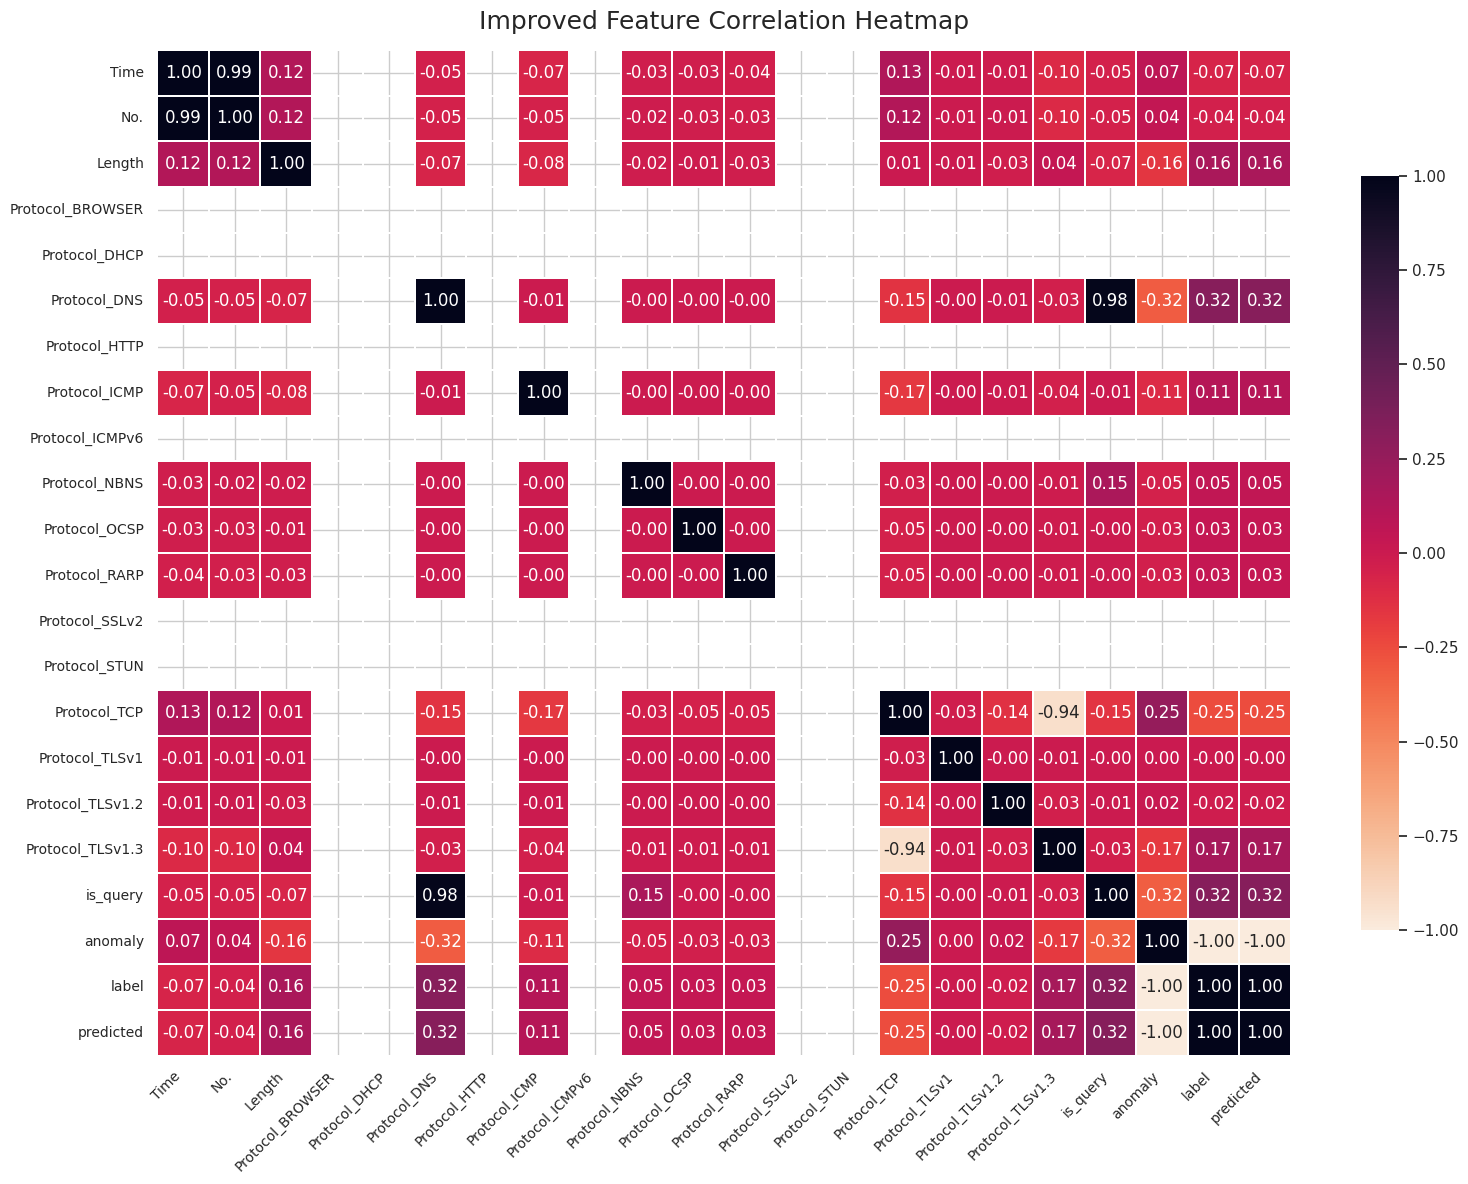

In [8]:
corr_matrix = sample_df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap="rocket_r",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"shrink": 0.75},
    square=False
)
plt.title("Improved Feature Correlation Heatmap", fontsize=18, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

#Confusion Matrix

<Figure size 600x400 with 0 Axes>

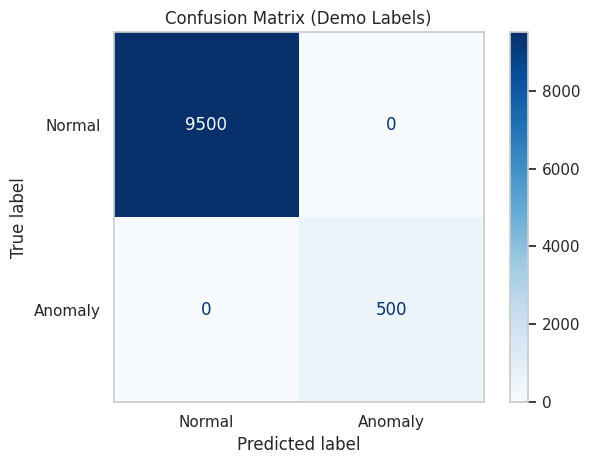

In [9]:
cm = confusion_matrix(sample_df["label"], sample_df["predicted"])
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Demo Labels)")
plt.grid(False)
plt.tight_layout()
plt.show()

#3D PCA Anomaly Detection

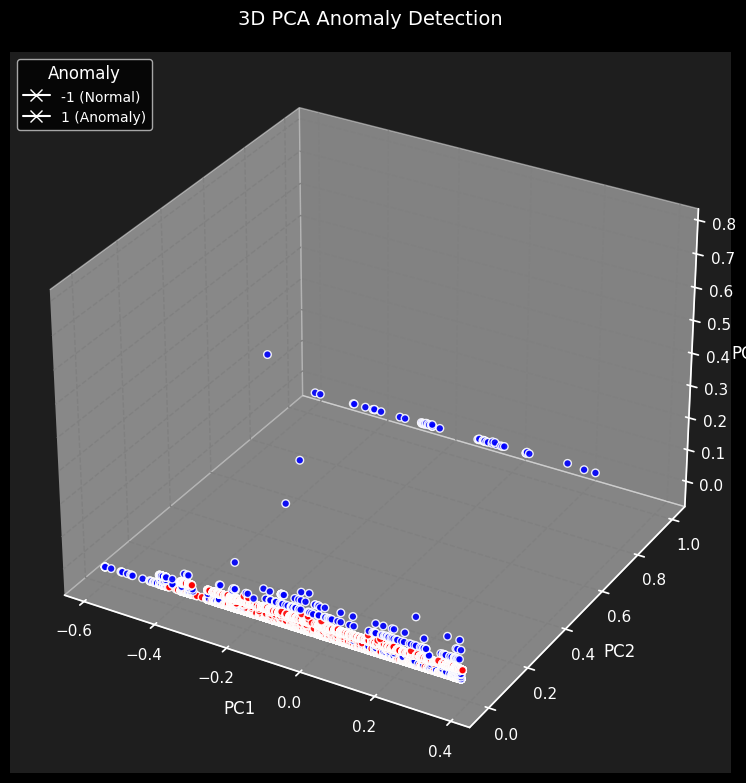

In [10]:
pca_3d_data = PCA(n_components=3).fit_transform(sample_df[["Time", "Length", "is_query"]])
plt.style.use('dark_background')
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d", facecolor="#1e1e1e")

colors = sample_df["anomaly"].map({-1: 'blue', 1: 'red'})
scatter = ax.scatter(
    pca_3d_data[:, 0],
    pca_3d_data[:, 1],
    pca_3d_data[:, 2],
    c=colors,
    s=30,
    alpha=0.9,
    edgecolor='white'
)

ax.set_title("3D PCA Anomaly Detection", color="white", fontsize=14, pad=20)
ax.set_xlabel("PC1", color="white")
ax.set_ylabel("PC2", color="white")
ax.set_zlabel("PC3", color="white")
ax.xaxis._axinfo["grid"].update(color="gray", linestyle="--")
ax.yaxis._axinfo["grid"].update(color="gray", linestyle="--")
ax.zaxis._axinfo["grid"].update(color="gray", linestyle="--")
ax.tick_params(colors="white")

legend_elements = [
    Line2D([0], [0], marker='x', color='w', label='-1 (Normal)', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='x', color='w', label='1 (Anomaly)', markerfacecolor='red', markersize=8)
]
ax.legend(handles=legend_elements, title="Anomaly", loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()
